# Notebook for Evaluation of Training

In [26]:
%load_ext autoreload
%autoreload 2

In [27]:
from encoding import *
from processing import *
from decoding import *
from visualize import *
from Trainer import *
from mesh import *
from baseline import *
from metrics import *
#from main import *
import numpy as np
import matplotlib.pyplot as plt
import os

## Load data

In [18]:
values = np.array([1,7])#figures you want from the mnist dataset
number = 200            #Sets number of samples you want to get in total
m_side = 10             #side length (pixel) of mnist image after downsampling
theta_enc = 1           #mysterious hyper parameter for amplitude scaling
norm_energy = True      #Bool for if energy of encoded image should be normalized or not
seed = 1550             #Random seed to control random choice of number -pictures out of the available ones, 
                        #seed = None leads to random results for each iteration
balanced = True         #Enforcing equality of classes
split_ratio = 0.8       #Sets training-sample proportion

E_train, Y_train, E_test, Y_test = get_data(values, number, m_side, 
                        theta_enc, norm_energy, seed, balanced, split_ratio)    
#E_* are the flattened arrays of the encoded mnist images (complex valued), 
#Y_* are the referring labels



Train:   160 samples, class counts {1: 80, 7: 80}
Test :    40 samples, class counts {1: 20, 7: 20}


## Creating training config

In [19]:
### CONFIG + MESH
cfg = TrainConfig(m_side=10, theta_enc=1, normalize_energy=True, encoding='amplitude', 
        detectors=(33,66), loss_kind='mse', learning_rate=0.3, batch_size=64,
                  init="random", max_epochs=10, patience=2, min_delta=0.01, 
                  param_init_seed=1550, eta_bs=1.0, alpha_fiber=0.0)
mesh = MZIMesh(cfg.N, plan_rectangular(cfg.N, cfg.N))

print(cfg)

TrainConfig(m_side=10, theta_enc=1, normalize_energy=True, encoding='amplitude', detectors=(33, 66), loss_kind='mse', learning_rate=0.3, batch_size=64, init='random', max_epochs=10, patience=2, min_delta=0.01, param_init_seed=1550, eta_bs=1.0, alpha_fiber=0.0)


## Initiating trainer and running fit

In [33]:
trainer = Trainer(mesh, cfg)
history = trainer.fit(E_train, Y_train)

Epoch 10.00/10 | Loss: 0.4656: 100%|██████████| 30/30.0 [00:10<00:00,  2.96it/s]


## Presenting results of fit

In [32]:
test_loss, test_acc = trainer.evaluate(E_test, Y_test)
print(f"validation acc {history['acc'][-1]:.4f} | test acc {test_acc:.4f} | "
      f"{len(history['loss'])} epochs, {trainer.train_time:.1f}s")
print(f"inference: {trainer.inference_time(E_test)*1e3:.2f} ms/sample")

validation acc 0.8938 | test acc 0.9000 | 10 epochs, 9.7s
inference: 10.77 ms/sample


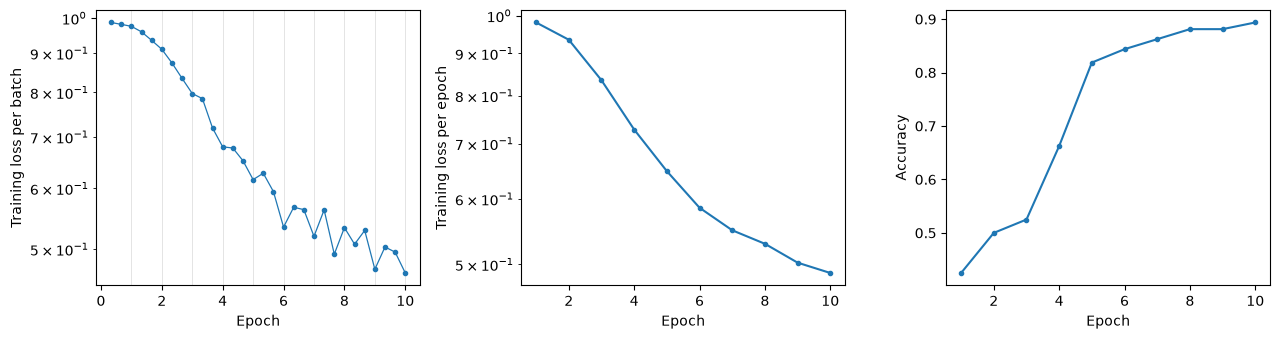

In [7]:
fig, _ = plot_training(trainer, keys=("batch_loss", "loss", "acc"))

## Saving results and reading them back

In [8]:
m="test"
trainer.save(f"results/{m}.json", test_acc=test_acc)

WindowsPath('results/test.json')

In [9]:
# laden
import os

trainer = Trainer.load(os.path.join(os.getcwd(),"results/test.json"))
print(trainer.extra["test_acc"])

0.9


## Running a sweep over an arbitrary parameter
Create a trainer instance for every sweep-position and give the whole array to "plot_training" in visualize.py

In [37]:
ms = [4, 6, 8]
trainers = []
for m in ms:
    cfg = TrainConfig(m_side=m, learning_rate=0.3, batch_size=50, param_init_seed=0, max_epochs=20)
    E_tr, y_tr, E_te, y_te = get_data(values, number=2000, m_side=m,
                                      theta_enc=1, normalize_energy=True,
                                      seed=1550, balanced=True, verbose=True)
    t = Trainer(MZIMesh(cfg.N, plan_rectangular(cfg.N, cfg.N)), cfg)
    t.fit(E_tr, y_tr)
    t.test_acc = t.evaluate(E_te, y_te)[1]      
    trainers.append(t)

Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 20.00/20 | Loss: 0.0476: 100%|██████████| 640/640.0 [00:04<00:00, 134.46it/s]


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 20.00/20 | Loss: 0.0196: 100%|██████████| 640/640.0 [00:21<00:00, 30.12it/s]


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 20.00/20 | Loss: 0.0071: 100%|██████████| 640/640.0 [01:17<00:00,  8.28it/s]


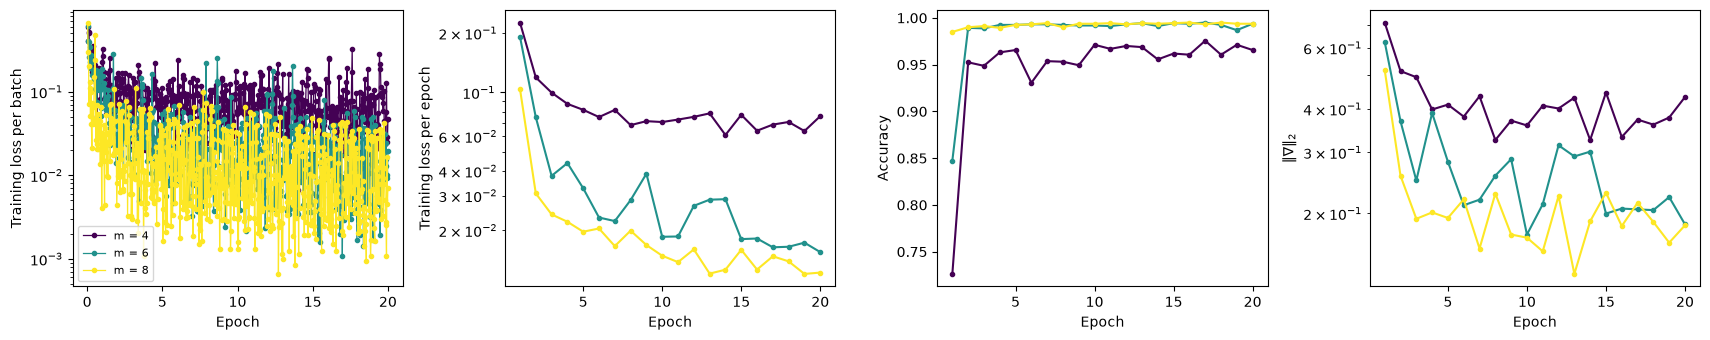

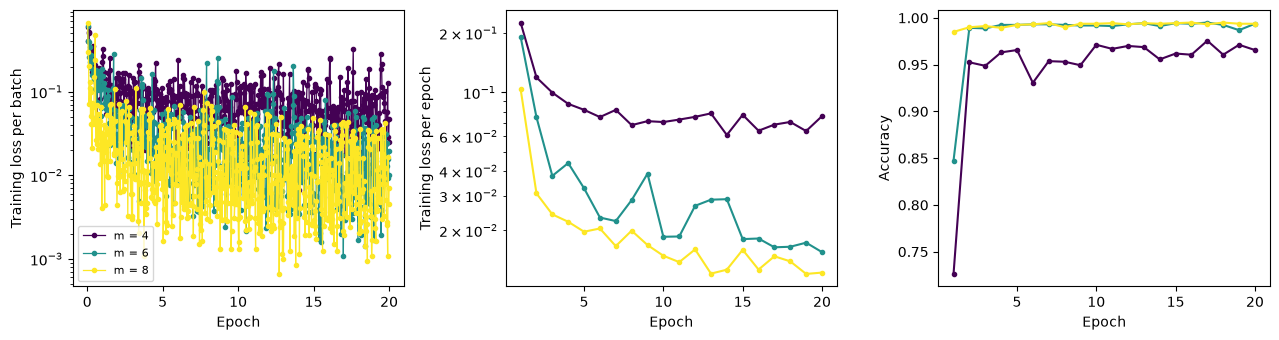

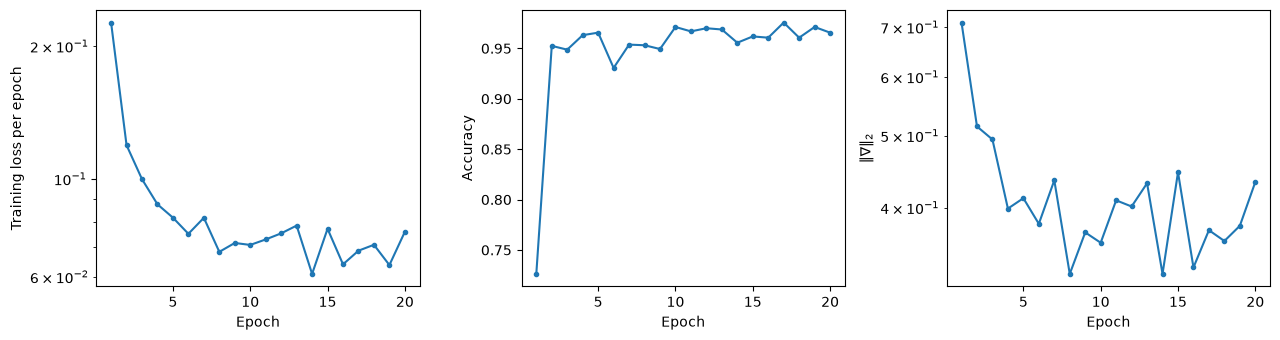

In [15]:
fig, _ = plot_training(trainers, sweep_values=ms, keys=("batch_loss", "loss", "acc", "grad_norm"))
#Von mir bevorzugter Plot
fig, _ = plot_training(trainers, sweep_values=ms, keys=("batch_loss", "loss", "acc"))

# Einzelner Lauf
fig, _ = plot_training(trainers[0])

# Reading data

## Learning rate

In [19]:
values = np.array([1,7])#figures you want from the mnist dataset
number = 2000            #Sets number of samples you want to get in total
m_side = 10             #side length (pixel) of mnist image after downsampling
theta_enc = 1           #mysterious hyper parameter for amplitude scaling
norm_energy = True      #Bool for if energy of encoded image should be normalized or not
seed = 1550             #Random seed to control random choice of number -pictures out of the available ones, 
                        #seed = None leads to random results for each iteration
balanced = True         #Enforcing equality of classes
split_ratio = 0.8       #Sets training-sample proportion

E_train, Y_train, E_test, Y_test = get_data(values, number, m_side, 
                        theta_enc, norm_energy, seed, balanced, split_ratio) 

trainers = []
sweep=[0.01, 0.03, 0.1, 0.3, 0.8,0.9,1.0,1.1,1.3,1.5,1.7,2.2,2.5,2.7,3,4,5.0,10.0,50.0] #all sweeps
sweep=[0.01, 0.03, 0.1, 0.3, 0.8,1.0,1.3,1.7,2.5,3,4,5.0,10.0,50.0] #relevant sweeps

sweep_label="learning_rate"
for s in sweep:
    t = Trainer.load(os.path.join(os.getcwd(),f"results/{sweep_label}/{s:.3f}.json"))
    test_loss, test_acc = t.evaluate(E_test, Y_test)
    trainers.append(t)

for s, t in zip(sweep, trainers):
    print(f"{sweep_label}={s}  epochs={len(t.history['loss']):3d} "
          f"loss={t.history['loss'][-1]:.5f}  "
          f"train acc={t.history['acc'][-1]:.4f}  "
          f"test acc={t.test_acc:.4f}  {t.train_time:.0f}s")

Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}
learning_rate=0.01  epochs= 35 loss=0.36199  train acc=0.9550  test acc=0.9600  308s
learning_rate=0.03  epochs= 35 loss=0.22018  train acc=0.9600  test acc=0.9700  306s
learning_rate=0.1  epochs= 35 loss=0.19508  train acc=0.9656  test acc=0.9700  305s
learning_rate=0.3  epochs= 26 loss=0.19363  train acc=0.9650  test acc=0.9750  227s
learning_rate=0.8  epochs= 16 loss=0.19447  train acc=0.9675  test acc=0.9700  317s
learning_rate=1.0  epochs= 16 loss=0.19505  train acc=0.9681  test acc=0.9700  207s
learning_rate=1.3  epochs= 16 loss=0.19596  train acc=0.9681  test acc=0.9700  144s
learning_rate=1.7  epochs= 16 loss=0.19744  train acc=0.9688  test acc=0.9700  142s
learning_rate=2.5  epochs= 31 loss=0.20066  train acc=0.9681  test acc=0.9775  272s
learning_rate=3  epochs= 35 loss=0.20292  train acc=0.9594  test acc=0.9700  318s
learning_rate=4  epochs= 13 loss=0.69056  train acc=0.93

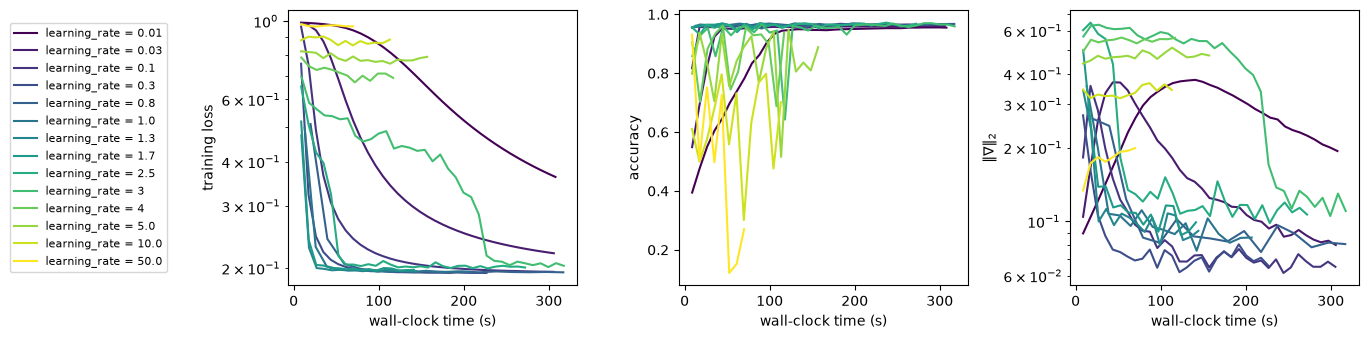

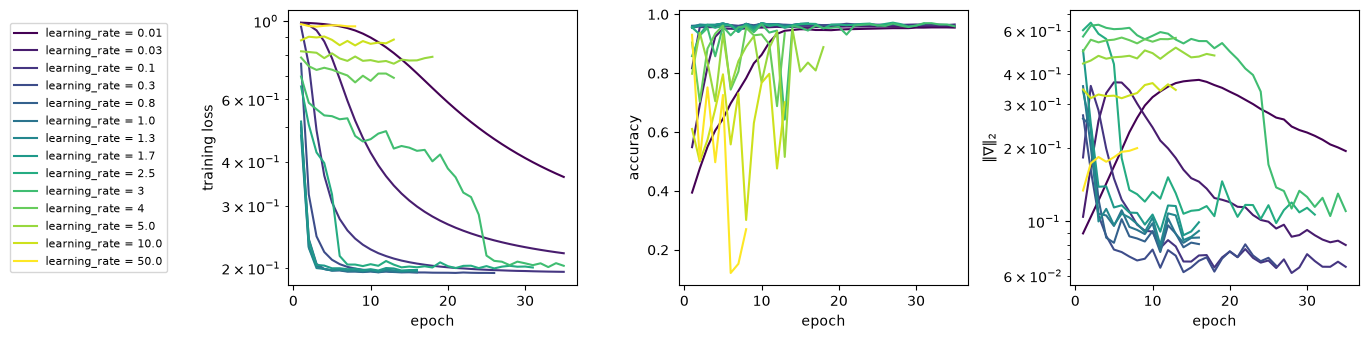

In [35]:
# Just plotting relevant sweeps
fig, _ = plot_training(trainers, sweep_values=sweep, sweep_label=sweep_label ,keys=("loss", "acc", "grad_norm"), x_axis="time")
# Just plotting relevant sweeps
fig, _ = plot_training(trainers, sweep_values=sweep, sweep_label=sweep_label ,keys=("loss", "acc", "grad_norm"), x_axis="epoch")


## Sidelength m

In [41]:
values = np.array([1,7])#figures you want from the mnist dataset
number = 2000            #Sets number of samples you want to get in total
m_side = 10             #side length (pixel) of mnist image after downsampling
theta_enc = 1           #mysterious hyper parameter for amplitude scaling
norm_energy = True      #Bool for if energy of encoded image should be normalized or not
seed = 1550             #Random seed to control random choice of number -pictures out of the available ones, 
                        #seed = None leads to random results for each iteration
balanced = True         #Enforcing equality of classes
split_ratio = 0.8       #Sets training-sample proportion

E_train, Y_train, E_test, Y_test = get_data(values, number, m_side, 
                        theta_enc, norm_energy, seed, balanced, split_ratio) 

trainers = []
sweep = [6,8,10,14,18,22]
sweep_label = "m_sidelength"

for s in sweep:
    t = Trainer.load(os.path.join(os.getcwd(),f"results/{sweep_label}/{s:.3f}.json"))
    #test_loss, test_acc = t.evaluate(E_test, Y_test)
    trainers.append(t)
    

for s, t in zip(sweep, trainers):
    print(f"{sweep_label}={s}  epochs={len(t.history['loss']):3d} "
          f"loss={t.history['loss'][-1]:.5f}  "
          f"train acc={t.history['acc'][-1]:.4f}  "
          f"test acc={t.test_acc:.4f}  {t.train_time:.0f}s")

Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}
m_sidelength=6  epochs=  5 loss=0.22518  train acc=0.9225  test acc=0.9400  5s
m_sidelength=8  epochs=  5 loss=0.18545  train acc=0.9600  test acc=0.9625  15s
m_sidelength=10  epochs=  5 loss=0.19703  train acc=0.9681  test acc=0.9775  38s
m_sidelength=14  epochs=  5 loss=0.22042  train acc=0.9700  test acc=0.9800  161s
m_sidelength=18  epochs=  5 loss=0.25275  train acc=0.9663  test acc=0.9750  596s
m_sidelength=22  epochs=  5 loss=0.24848  train acc=0.9644  test acc=0.9750  1416s


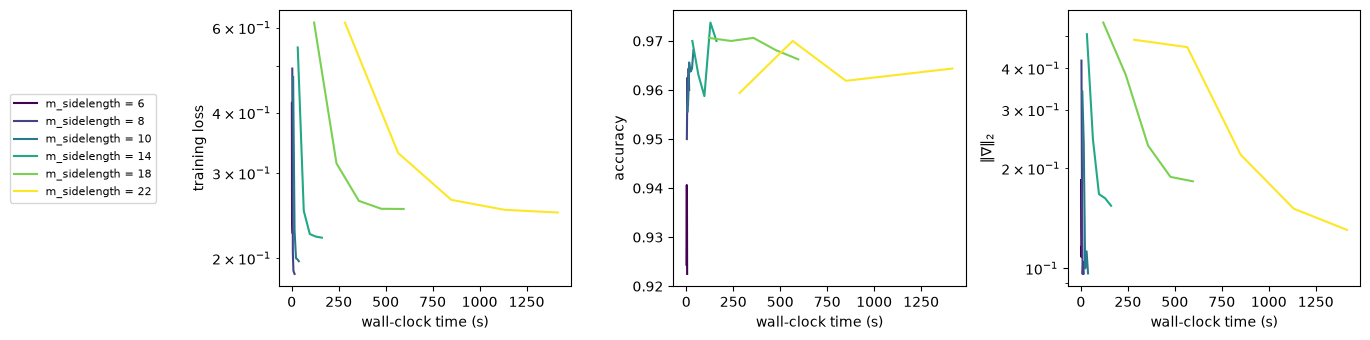

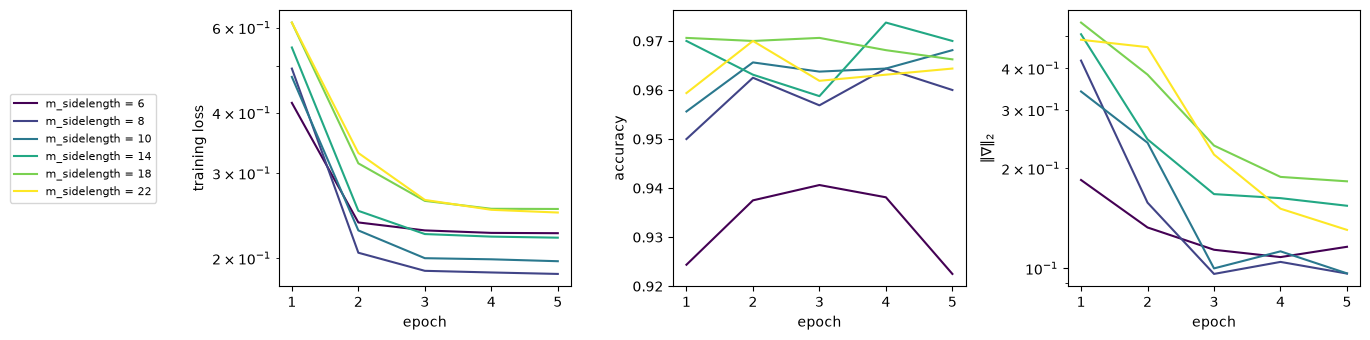

In [42]:
# Just plotting relevant sweeps
fig, _ = plot_training(trainers, sweep_values=sweep, sweep_label=sweep_label ,keys=("loss", "acc", "grad_norm"), x_axis="time")
# Just plotting relevant sweeps
fig, _ = plot_training(trainers, sweep_values=sweep, sweep_label=sweep_label ,keys=("loss", "acc", "grad_norm"), x_axis="epoch")
